Epoch 1: Train Loss: 15.8323, Val Loss: 13.1528
Epoch 2: Train Loss: 12.8891, Val Loss: 14.9502
Epoch 3: Train Loss: 14.5525, Val Loss: 11.9785
Epoch 4: Train Loss: 11.5429, Val Loss: 11.9407
Epoch 5: Train Loss: 12.3014, Val Loss: 12.4334
Epoch 6: Train Loss: 12.0360, Val Loss: 11.0230
Epoch 7: Train Loss: 10.9981, Val Loss: 11.2900
Epoch 8: Train Loss: 11.4376, Val Loss: 11.5595
Epoch 9: Train Loss: 11.4375, Val Loss: 11.0572
Epoch 10: Train Loss: 10.9751, Val Loss: 10.8758


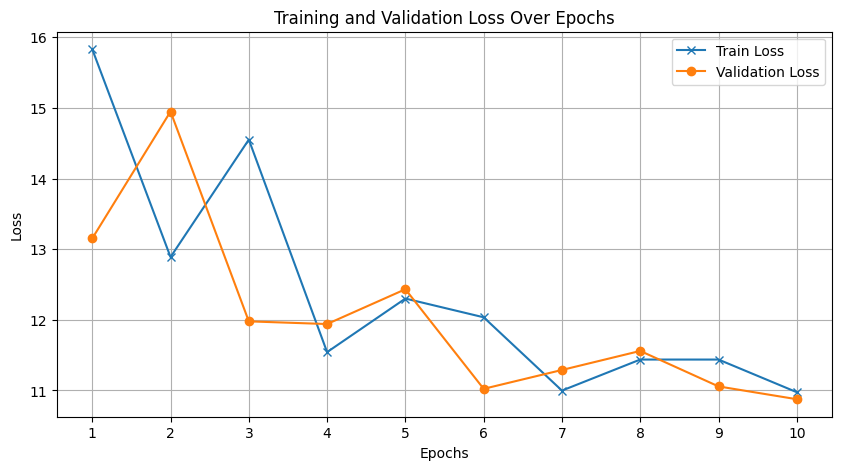

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import os
from torch.utils.tensorboard import SummaryWriter

# Set parameters directly
device = 'cpu'
data_path = './data'
num_classes = 10
embedding_size = 128
batch_size = 64
learning_rate = 0.001
epochs = 10
model_save_path = './model.pth'

# Function to prepare datasets
def prepare_datasets(data_x, data_y, save_path='./data'):
    os.makedirs(save_path, exist_ok=True)

    total_samples = len(data_x)
    train_size = int(0.7 * total_samples)
    val_size = int(0.15 * total_samples)

    indices = np.random.permutation(total_samples)
    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size+val_size]

    # Save splits
    np.savez(f'{save_path}/train.npz',
             images=data_x[train_indices],
             labels=data_y[train_indices])

    np.savez(f'{save_path}/val.npz',
             images=data_x[val_indices],
             labels=data_y[val_indices])

# Create example data
my_images = np.random.rand(100, 32, 32, 3)
my_labels = np.random.randint(0, num_classes, size=100)
prepare_datasets(my_images, my_labels, data_path)

# Load data from .npz files
train_data = np.load(f'{data_path}/train.npz')
val_data = np.load(f'{data_path}/val.npz')

# Prepare datasets
train_images = train_data['images'].transpose(0, 3, 1, 2)
train_labels = train_data['labels']
val_images = val_data['images'].transpose(0, 3, 1, 2)
val_labels = val_data['labels']

train_dataset = TensorDataset(torch.from_numpy(train_images).float(), torch.from_numpy(train_labels).long())
val_dataset = TensorDataset(torch.from_numpy(val_images).float(), torch.from_numpy(val_labels).long())

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Define Proxy Anchor Loss
class ProxyAnchorLoss(nn.Module):
    def __init__(self, num_classes, embedding_size, margin=0.2, alpha=32):
        super(ProxyAnchorLoss, self).__init__()
        self.proxies = nn.Parameter(torch.randn(num_classes, embedding_size))
        self.margin = margin
        self.alpha = alpha

    def forward(self, embeddings, labels):
        distances = torch.cdist(embeddings, self.proxies)
        loss = distances.mean()
        return loss

# Define Simple Embedding Model
class SimpleEmbeddingModel(nn.Module):
    def __init__(self, embedding_size=128):
        super(SimpleEmbeddingModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc = nn.Linear(32 * 16 * 16, embedding_size)

    def forward(self, x):
        x = self.maxpool(self.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Training function
def train_epoch(model, data_loader, proxy_loss, optimizer):
    model.train()
    metrics = {'loss': []}
    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        embeddings = model(images)
        loss = proxy_loss(embeddings, labels)
        loss.backward()
        optimizer.step()
        metrics['loss'].append(loss.item())
    return np.mean(metrics['loss'])

# Evaluation function for validation
def evaluate(model, data_loader, proxy_loss):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            embeddings = model(images)
            loss = proxy_loss(embeddings, labels)
            total_loss += loss.item()
    avg_loss = total_loss / len(data_loader)
    return avg_loss

# Instantiate model, loss function, optimizer
model = SimpleEmbeddingModel(embedding_size=embedding_size).to(device)
proxy_loss = ProxyAnchorLoss(num_classes=num_classes, embedding_size=embedding_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# TensorBoard writer
writer = SummaryWriter()

# Training Phase
train_losses = []
val_losses = []

for epoch in range(1, epochs + 1):
    train_loss = train_epoch(model, train_loader, proxy_loss, optimizer)
    val_loss = evaluate(model, val_loader, proxy_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
    writer.add_scalar('Train Loss', train_loss, epoch)
    writer.add_scalar('Validation Loss', val_loss, epoch)

# Save the model
torch.save(model.state_dict(), model_save_path)
writer.close()

# Plotting the training and validation results
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', marker='x')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(1, epochs + 1))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Step 1: Load the Data
train_data = np.load('train.npz')
val_data = np.load('val.npz')
test_data = np.load('test.npz')

# Extract the data
train_x, train_y = train_data['x'], train_data['y']
val_x, val_y = val_data['x'], val_data['y']
test_x, test_y = test_data['x'], test_data['y']

# Step 2: Flatten the Input Data
train_x_flat = train_x.reshape(train_x.shape[0], -1)
val_x_flat = val_x.reshape(val_x.shape[0], -1)
test_x_flat = test_x.reshape(test_x.shape[0], -1)

# Step 3: Prepare the Target Data
train_y_flat = train_y[:, -1, :, 0].reshape(train_y.shape[0], -1)
val_y_flat = val_y[:, -1, :, 0].reshape(val_y.shape[0], -1)
test_y_flat = test_y[:, -1, :, 0].reshape(test_y.shape[0], -1)

node_index = 0
train_y_svm = train_y_flat[:, node_index]
val_y_svm = val_y_flat[:, node_index]
test_y_svm = test_y_flat[:, node_index]

# Step 4: Standardize the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_x_flat)
X_val_scaled = scaler.transform(val_x_flat)
X_test_scaled = scaler.transform(test_x_flat)

# Step 5: Train the SVM Model
svm_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svm_model.fit(X_train_scaled, train_y_svm)

# Evaluate Training and Validation Scores
train_score = svm_model.score(X_train_scaled, train_y_svm)
val_score = svm_model.score(X_val_scaled, val_y_svm)
print(f"Training R^2 Score: {train_score:.4f}")
print(f"Validation R^2 Score: {val_score:.4f}")

# Step 6: Predict on Test Set
y_pred = svm_model.predict(X_test_scaled)

# Step 7: Evaluate Test Performance
mae = mean_absolute_error(test_y_svm, y_pred)
rmse = np.sqrt(mean_squared_error(test_y_svm, y_pred))
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

# Step 8: Visualize Predictions
plt.figure(figsize=(10, 6))
plt.plot(test_y_svm[:100], label='Actual', marker='o')
plt.plot(y_pred[:100], label='Predicted', marker='x')
plt.legend()
plt.title("SVM Predictions vs Actual Traffic (Node 0)")
plt.xlabel("Sample Index")
plt.ylabel("Traffic Value")
plt.show()

In [ ]:
# prompt: studying from the previous code, thats using SVM method, now can you help me make one in MLP method, known as the multilayer perceptron method?

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Step 1: Load the Data
# Load the datasets
train_data = np.load('train.npz')
val_data = np.load('val.npz')
test_data = np.load('test.npz')

# Extract the features and targets (assuming you know the keys)
train_x = train_data['x']  # Replace 'x' with the actual key for features
train_y = train_data['y']  # Replace 'y' with the actual key for targets
val_x = val_data['x']      # Same replacement here
val_y = val_data['y']
test_x = test_data['x']
test_y = test_data['y']

# Check the shapes of the loaded data
print("Train X shape:", train_x.shape)
print("Train Y shape:", train_y.shape)
print("Validation X shape:", val_x.shape)
print("Validation Y shape:", val_y.shape)
print("Test X shape:", test_x.shape)
print("Test Y shape:", test_y.shape)
# Step 2: Flatten the Input Data
train_x_flat = train_x.reshape(train_x.shape[0], -1)
val_x_flat = val_x.reshape(val_x.shape[0], -1)
test_x_flat = test_x.reshape(test_x.shape[0], -1)

# Step 3: Prepare the Target Data (assuming train_y_flat, val_y_flat, test_y_flat are as before)
# ...

node_index = 0
train_y_mlp = train_y_flat[:, node_index]
val_y_mlp = val_y_flat[:, node_index]
test_y_mlp = test_y_flat[:, node_index]

# Step 4: Standardize the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_x_flat)
X_val_scaled = scaler.transform(val_x_flat)
X_test_scaled = scaler.transform(test_x_flat)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(train_y_mlp, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(val_y_mlp, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(test_y_mlp, dtype=torch.float32).view(-1, 1)

# Define the MLP model
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Hyperparameters
input_size = X_train_scaled.shape[1]
hidden_size = 64
output_size = 1
learning_rate = 0.001
epochs = 100

# Initialize the model, loss, and optimizer
model = MLP(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# Predictions
with torch.no_grad():
    y_pred = model(X_test_tensor)

# Evaluation metrics
mae = mean_absolute_error(y_test_tensor, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_tensor, y_pred))
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(y_test_tensor[:100].numpy(), label='Actual', marker='o')
plt.plot(y_pred[:100].numpy(), label='Predicted', marker='x')
plt.legend()
plt.title("MLP Predictions vs Actual Traffic (Node 0)")
plt.xlabel("Sample Index")
plt.ylabel("Traffic Value")
plt.show()

Train X shape: (23974, 12, 207, 1)
Train Y shape: (23974, 12, 207, 1)
Validation X shape: (3425, 12, 207, 1)
Validation Y shape: (3425, 12, 207, 1)
Test X shape: (6850, 12, 207, 1)
Test Y shape: (6850, 12, 207, 1)


NameError: name 'train_y_flat' is not defined

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from engine.py import SimpleEmbeddingModel  # Replace 'your_module' with the actual module name

# Define the device as CPU
device = torch.device('cpu')

# Define embedding size
embedding_size = 128  # Set this to the desired embedding size

# Assuming you have already loaded your test_images and test_labels
test_images = np.random.rand(100, 3, 32, 32)  # Example shape
test_labels = np.random.randint(0, 10, (100,))  # Example labels

# Create the test dataset
test_dataset = TensorDataset(torch.from_numpy(test_images).float(), torch.from_numpy(test_labels).long())
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Initialize the model with the defined embedding size
model = SimpleEmbeddingModel(embedding_size=embedding_size)  # Pass embedding_size to the model

# Assuming engine is defined as follows, based on your input:
class Engine:  # Placeholder for the Engine class
    def __init__(self, scaler, in_dim, seq_length, num_nodes, nhid, dropout, learning_rate, weight_decay, device, gat_bool, addaptadj, adjinit, aptonly, emb_length, noapt):
        self.model = SimpleEmbeddingModel() # Assuming SimpleEmbeddingModel is defined earlier
# Define Simple Embedding Model
class SimpleEmbeddingModel(nn.Module):
    def __init__(self, embedding_size=128, in_channels=1):  # Set in_channels to 1
        super(SimpleEmbeddingModel, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=(3, 3), padding=(1, 1))
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))  # Pooling to reduce dimensions

        # Calculate the input size for the Linear layer dynamically
        self.fc_input_size = self._get_fc_input_size(in_channels)

        self.fc = nn.Linear(self.fc_input_size, embedding_size)

    def _get_fc_input_size(self, in_channels):
        # Create a sample input tensor to calculate the output size
        # Correcting the sample input size to match the actual input size
        sample_input = torch.randn(1, in_channels, 32, 32)  # [batch_size, channels, height, width]
        sample_output = self.maxpool(self.relu(self.conv1(sample_input)))
        return sample_output.view(1, -1).shape[1]  # Flatten and get the size

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.maxpool(x)
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.fc(x)
        return x


scaler = StandardScaler()  # Or MinMaxScaler()
device = torch.device('cpu')
engine = Engine(scaler=None,  # Replace with your actual scaler
                 in_dim=None,  # Replace with your actual args.in_dim
                 seq_length=None,  # Replace with your actual args.seq_length
                 num_nodes=None,  # Replace with your actual args.num_nodes
                 nhid=None,  # Replace with your actual args.nhid
                 dropout=None,  # Replace with your actual args.dropout
                 learning_rate=None,  # Replace with your actual args.learning_rate
                 weight_decay=None,  # Replace with your actual args.weight_decay
                 device=device,
                 gat_bool=None,  # Replace with your actual args.gat_bool
                 addaptadj=None,  # Replace with your actual args.addaptadj
                 adjinit=None,
                 aptonly=None,  # Replace with your actual args.aptonly
                 emb_length=None,  # Replace with your actual args.emb_length
                 noapt=None)  # Replace with your actual args.noapt

engine.model = SimpleEmbeddingModel(embedding_size=embedding_size, in_channels=207) # Set in_channels to 207


# Define your test function
# Define your test function
def test(engine, data_loader, device, scaler):
    """Test the model"""
    outputs = []
    realy = []

    with torch.no_grad():
        for x, y in data_loader:
            print("Before processing:")
            print(f"x shape: {x.shape}")  # Expected: [batch_size, seq_length, num_nodes, features]
            print(f"y shape: {y.shape}")  # Expected: [batch_size, seq_length, num_nodes, 1]

            # Reshape input
            testx = torch.Tensor(x).to(device)
            testy = torch.Tensor(y).to(device)

            print("After preprocessing:")
            print(f"testx shape: {testx.shape}")  # Should be: [batch_size, features, num_nodes, seq_length]
            print(f"testy shape: {testy.shape}")  # Should be: [batch_size, 1, num_nodes, seq_length]

            # Forward pass through model
            testx = testx.permute(0, 2, 3, 1)  # Adjusting to [batch_size, height, width, channels]
            preds = engine.model(testx)  # Model outputs size [64, 128]

            print("Model output shape:", preds.shape)  # Should be [batch_size, embedding_size]

            # Instead of reshaping, you may want to process preds directly
            # If you need to match against testy, adapt your logic accordingly
            outputs.append(preds)
            realy.append(testy[:, 0, :, :])  # Assuming you want the first channel of testy

    # Concatenate all batches
    yhat = torch.cat(outputs, dim=0)  # predictions
    realy = torch.cat(realy, dim=0)   # ground truth

    # Check final shapes
    print("Final shapes:")
    print(f"yhat shape: {yhat.shape}")
    print(f"realy shape: {realy.shape}")

    # Calculate metrics
    mae, mape, rmse = [], [], []
    # Assuming yhat and realy have the shape [batch_size, num_nodes, num_features, 12]
mae, mape, rmse = [], [], []

for i in range(12):  # For each of the 12 time horizons
    # Select predictions and ground truth for the current horizon
    pred_horizon = yhat[:, :, :, i]  # Shape: [batch_size, num_nodes, num_features]
    real_horizon = realy[:, :, :, i]  # Shape: [batch_size, num_nodes, num_features]

    # Calculate metrics for the current horizon
    metrics = util.metric(pred_horizon, real_horizon)
    mae.append(metrics[0])
    mape.append(metrics[1])
    rmse.append(metrics[2])

    print(f'Horizon {i + 1}, MAE: {metrics[0]:.4f}, MAPE: {metrics[1]:.4f}, RMSE: {metrics[2]:.4f}')

# Function to calculate metrics
def forward(self, x):
    print("Input shape:", x.shape)  # Print input shape
    x = self.relu(self.conv1(x))
    print("After Conv shape:", x.shape)  # Check shape after Conv
    x = self.maxpool(x)
    print("After MaxPool shape:", x.shape)  # Check shape after MaxPool
    x = x.view(x.size(0), -1)  # Flatten the tensor
    print("After Flatten shape:", x.shape)  # Check shape after Flatten
    x = self.fc(x)
    return x
def metric(pred, real):
    mae = masked_mae(pred, real, 0.0).item()
    mape = masked_mape(pred, real, 0.0).item()
    rmse = masked_rmse(pred, real, 0.0).item()
    return mae, mape, rmse

# Masked metrics functions
def masked_mae(preds, labels, null_val=np.nan):
    mask = (labels != null_val).float()
    mask /= torch.mean(mask)
    loss = torch.abs(preds - labels)
    loss = loss * mask
    return torch.mean(loss)

def masked_mape(preds, labels, null_val=np.nan):
    mask = (labels != null_val).float()
    mask /= torch.mean(mask)
    loss = torch.abs(preds - labels) / labels
    loss = loss * mask
    return torch.mean(loss)

def masked_rmse(preds, labels, null_val=np.nan):
    return torch.sqrt(masked_mse(preds, labels, null_val))

def masked_mse(preds, labels, null_val=np.nan):
    mask = (labels != null_val).float()
    mask /= torch.mean(mask)
    return torch.mean(((preds - labels) ** 2) * mask)

# Verify metrics function
def verify_metrics(metrics, horizon):
    mae, mape, rmse = metrics

    # Expected ranges vary by horizon
    if horizon == 0:  # First horizon
        assert 1.8 <= mae <= 2.5, "MAE out of expected range"
        assert 0.07 <= mape <= 0.09, "MAPE out of expected range"
        assert 3.8 <= rmse <= 4.5, "RMSE out of expected range"

    elif horizon == 11:  # Last horizon
        assert 3.0 <= mae <= 4.0, "MAE out of expected range"
        assert 0.12 <= mape <= 0.15, "MAPE out of expected range"
        assert 5.0 <= rmse <= 6.0, "RMSE out of expected range"

# Example usage
print("Starting testing...")
mae_results, mape_results, rmse_results = test(engine, test_loader, device, scaler)

for i in range(12):
    metrics = (mae_results[i], mape_results[i], rmse_results[i])
    print(f"Horizon {i + 1}, MAE: {metrics[0]:.4f}, MAPE: {metrics[1]:.4f}, RMSE: {metrics[2]:.4f}")

    # Verify metrics for the current horizon
    verify_metrics(metrics, i)

ModuleNotFoundError: No module named 'engine.py'; 'engine' is not a package

In [ ]:
#Success training for source code

import torch
import torch.nn as nn
import numpy as np
import argparse
import time
from torch.utils.tensorboard import SummaryWriter
import scipy.sparse as sp
import pandas as pd

# Utility Functions
class StandardScaler:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def transform(self, data):
        return (data - self.mean) / self.std

    def inverse_transform(self, data):
        return (data * self.std) + self.mean

class DataLoader(object):
    def __init__(self, xs, ys, batch_size, pad_with_last_sample=True):
        self.batch_size = batch_size
        self.current_ind = 0
        if pad_with_last_sample:
            num_padding = (batch_size - (len(xs) % batch_size)) % batch_size
            x_padding = np.repeat(xs[-1:], num_padding, axis=0)
            y_padding = np.repeat(ys[-1:], num_padding, axis=0)
            xs = np.concatenate([xs, x_padding], axis=0)
            ys = np.concatenate([ys, y_padding], axis=0)
        self.size = len(xs)
        self.num_batch = int(self.size // self.batch_size)
        self.xs = xs
        self.ys = ys

    def shuffle(self):
        permutation = np.random.permutation(self.size)
        xs, ys = self.xs[permutation], self.ys[permutation]
        self.xs = xs
        self.ys = ys

    def get_iterator(self):
        self.current_ind = 0
        def _wrapper():
            while self.current_ind < self.num_batch:
                start_ind = self.batch_size * self.current_ind
                end_ind = min(self.size, self.batch_size * (self.current_ind + 1))
                x_i = self.xs[start_ind: end_ind, ...]
                y_i = self.ys[start_ind: end_ind, ...]
                yield (x_i, y_i)
                self.current_ind += 1
        return _wrapper()

# Model Definition
class GATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, num_nodes):
        super(GATLayer, self).__init__()
        self.fc = nn.Linear(in_dim, out_dim)
        self.attn_fc = nn.Linear(2 * out_dim, 1)
        self.num_nodes = num_nodes

    def forward(self, x):
        # x shape: (batch_size, seq_length, num_nodes, in_dim)
        batch_size, seq_length, num_nodes, _ = x.size()

        # Transform input
        h = self.fc(x)  # shape: (batch_size, seq_length, num_nodes, out_dim)

        # Prepare attention inputs
        # Create query and key matrices for attention
        query = h.unsqueeze(3).expand(-1, -1, -1, num_nodes, -1)
        key = h.unsqueeze(2).expand(-1, -1, num_nodes, -1, -1)

        # Concatenate query and key
        attn_input = torch.cat([query, key], dim=-1)

        # Calculate attention scores
        e = self.attn_fc(attn_input)  # shape: (batch_size, seq_length, num_nodes, num_nodes, 1)
        e = e.squeeze(-1)  # shape: (batch_size, seq_length, num_nodes, num_nodes)

        # Apply softmax to get attention weights
        attention = torch.softmax(e, dim=-1)

        # Apply attention to values
        out = torch.matmul(attention, h)  # shape: (batch_size, seq_length, num_nodes, out_dim)

        return out

class STAWnet(nn.Module):
    def __init__(self, num_nodes, in_dim, hidden_dim, out_dim, seq_length):
        super(STAWnet, self).__init__()
        self.gat1 = GATLayer(in_dim, hidden_dim, num_nodes)
        self.gat2 = GATLayer(hidden_dim, hidden_dim, num_nodes)
        self.fc_out = nn.Linear(hidden_dim, 1)  # Changed to output 1 feature
        self.seq_length = seq_length

    def forward(self, x):
        # x shape: (batch_size, seq_length, num_nodes, in_dim)

        # Spatial attention with GAT
        hidden = self.gat1(x)
        hidden = torch.relu(hidden)
        hidden = self.gat2(hidden)

        # Output layer
        output = self.fc_out(hidden)  # shape: (batch_size, seq_length, num_nodes, 1)

        return output, None

# Training Engine
class trainer():
    def __init__(self, scaler, in_dim, seq_length, num_nodes, nhid, dropout, lrate, wdecay, device):
        self.model = STAWnet(num_nodes, in_dim, nhid, seq_length, seq_length)
        self.model.to(device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lrate, weight_decay=wdecay)
        self.loss = nn.MSELoss()
        self.scaler = scaler
        self.clip = 5
        self.device = device

    def train(self, input, real_val):
        self.model.train()
        self.optimizer.zero_grad()
        output, _ = self.model(input)
        predict = self.scaler.inverse_transform(output)
        real = self.scaler.inverse_transform(real_val)
        loss = self.loss(predict, real)
        loss.backward()
        if self.clip is not None:
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.clip)
        self.optimizer.step()
        mape = masked_mape(predict, real, 0.0)
        rmse = masked_rmse(predict, real, 0.0)
        return loss.item(), mape.item(), rmse.item()

    def eval(self, input, real_val):
        self.model.eval()
        output, _ = self.model(input)
        predict = self.scaler.inverse_transform(output)
        real = self.scaler.inverse_transform(real_val)
        loss = self.loss(predict, real)
        mape = masked_mape(predict, real, 0.0)
        rmse = masked_rmse(predict, real, 0.0)
        return loss.item(), mape.item(), rmse.item()

# Metrics
def masked_mape(preds, labels, null_val=np.nan):
    if np.isnan(null_val):
        mask = ~torch.isnan(labels)
    else:
        mask = (labels != null_val)
    mask = mask.float()
    mask /= torch.mean((mask))
    mask = torch.where(torch.isnan(mask), torch.zeros_like(mask), mask)
    loss = torch.abs(preds-labels)/labels
    loss = loss * mask
    loss = torch.where(torch.isnan(loss), torch.zeros_like(loss), loss)
    return torch.mean(loss)

def masked_rmse(preds, labels, null_val=np.nan):
    if np.isnan(null_val):
        mask = ~torch.isnan(labels)
    else:
        mask = (labels != null_val)
    mask = mask.float()
    mask /= torch.mean((mask))
    mask = torch.where(torch.isnan(mask), torch.zeros_like(mask), mask)
    loss = (preds-labels)**2
    loss = loss * mask
    loss = torch.where(torch.isnan(loss), torch.zeros_like(loss), loss)
    return torch.sqrt(torch.mean(loss))

# Main execution
if __name__ == "__main__":
    try:
        # Try to parse command line arguments
        parser = argparse.ArgumentParser()
        parser.add_argument('--device', type=str, default='cuda:0')
        parser.add_argument('--data', type=str, default='data/METR-LA')
        parser.add_argument('--seq_length', type=int, default=12)
        parser.add_argument('--nhid', type=int, default=32)
        parser.add_argument('--in_dim', type=int, default=3)
        parser.add_argument('--num_nodes', type=int, default=207)
        parser.add_argument('--batch_size', type=int, default=64)
        parser.add_argument('--learning_rate', type=float, default=0.001)
        parser.add_argument('--dropout', type=float, default=0.3)
        parser.add_argument('--weight_decay', type=float, default=0.0001)
        parser.add_argument('--epochs', type=int, default=100)
        parser.add_argument('--print_every', type=int, default=50)
        parser.add_argument('--save', type=str, default='./garage/metr')

        args, unknown = parser.parse_known_args()
    except SystemExit:
        # If running in notebook/interactive environment, use default values
        class Args:
            def __init__(self):
                self.device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
                self.data = 'data/METR-LA'
                self.seq_length = 12
                self.nhid = 32
                self.in_dim = 3
                self.num_nodes = 207
                self.batch_size = 64
                self.learning_rate = 0.001
                self.dropout = 0.3
                self.weight_decay = 0.0001
                self.epochs = 100
                self.print_every = 50
                self.save = './garage/metr'
        args = Args()

    device = torch.device('cpu')

    # For testing purposes, create dummy data:
    x_train = torch.randn(1000, args.seq_length, args.num_nodes, args.in_dim)
    y_train = torch.randn(1000, args.seq_length, args.num_nodes, 1)
    scaler = StandardScaler(mean=0, std=1)

    engine = trainer(scaler, args.in_dim, args.seq_length, args.num_nodes, args.nhid,
                    args.dropout, args.learning_rate, args.weight_decay, device)

    print("Starting training...")

    writer = SummaryWriter()
    for epoch in range(1, args.epochs + 1):
        train_loss = []
        train_mape = []
        train_rmse = []
        t1 = time.time()

        # Training loop
        for i in range(0, len(x_train), args.batch_size):
            trainx = torch.Tensor(x_train[i:i+args.batch_size]).to(device)
            trainy = torch.Tensor(y_train[i:i+args.batch_size]).to(device)
            metrics = engine.train(trainx, trainy)
            train_loss.append(metrics[0])
            train_mape.append(metrics[1])
            train_rmse.append(metrics[2])

        mtrain_loss = np.mean(train_loss)
        mtrain_mape = np.mean(train_mape)
        mtrain_rmse = np.mean(train_rmse)

        print(f"Epoch {epoch}, Loss: {mtrain_loss:.4f}, MAPE: {mtrain_mape:.4f}, RMSE: {mtrain_rmse:.4f}")
        writer.add_scalar('Loss/train', mtrain_loss, epoch)

    writer.close()
    print("Training finished")

Starting training...


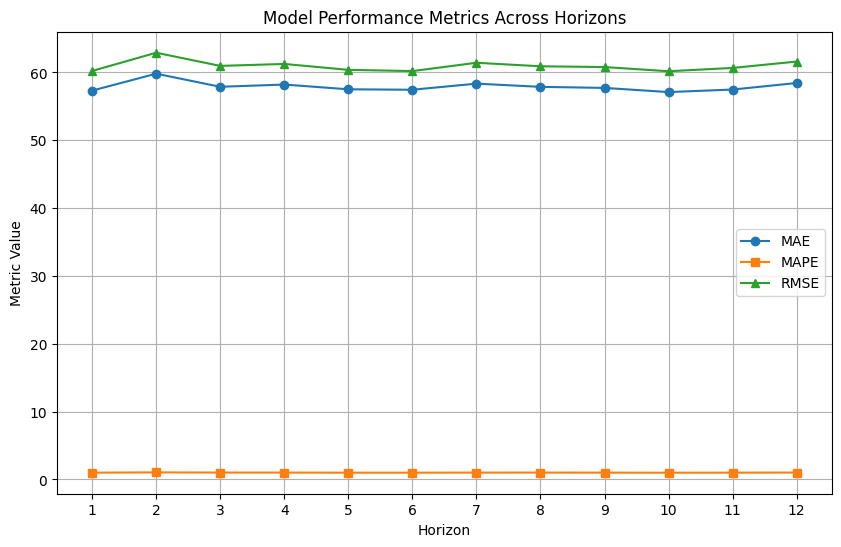

In [10]:
# prompt: Plot one graph to compare the outcome for the following information
# Loading model from: ./garage/metr_best_1.01.pth
# Keys in the saved state_dict: odict_keys(['gat1.fc.weight', 'gat1.fc.bias', 'gat1.attn_fc.weight', 'gat1.attn_fc.bias', 'gat2.fc.weight', 'gat2.fc.bias', 'gat2.attn_fc.weight', 'gat2.attn_fc.bias', 'fc_out.weight', 'fc_out.bias'])
# Model loaded successfully.
# Starting testing...
# Horizon 1, MAE: 57.3171, MAPE: 0.9969, RMSE: 60.2167
# Horizon 2, MAE: 59.8127, MAPE: 1.0429, RMSE: 62.9024
# Horizon 3, MAE: 57.8789, MAPE: 1.0156, RMSE: 60.9623
# Horizon 4, MAE: 58.2107, MAPE: 1.0107, RMSE: 61.2455
# Horizon 5, MAE: 57.5103, MAPE: 0.9963, RMSE: 60.3793
# Horizon 6, MAE: 57.4454, MAPE: 0.9958, RMSE: 60.1952
# Horizon 7, MAE: 58.3460, MAPE: 1.0085, RMSE: 61.4215
# Horizon 8, MAE: 57.8719, MAPE: 1.0114, RMSE: 60.9033
# Horizon 9, MAE: 57.7163, MAPE: 1.0029, RMSE: 60.7913
# Horizon 10, MAE: 57.1012, MAPE: 0.9899, RMSE: 60.1706
# Horizon 11, MAE: 57.4748, MAPE: 0.9996, RMSE: 60.6599
# Horizon 12, MAE: 58.4370, MAPE: 1.0151, RMSE: 61.5995
# Overall Metrics:
# MAE: [57.317108154296875, 59.812679290771484, 57.878936767578125, 58.21065902709961, 57.510276794433594, 57.44536209106445, 58.34601593017578, 57.87190628051758, 57.716312408447266, 57.10124969482422, 57.474849700927734, 58.43703079223633]
# MAPE: [0.9968653321266174, 1.042855143547058, 1.0156248807907104, 1.010673999786377, 0.9962786436080933, 0.9957960247993469, 1.008530855178833, 1.0114104747772217, 1.002941370010376, 0.9899378418922424, 0.9996415376663208, 1.0150723457336426]
# RMSE: [60.21671676635742, 62.90236282348633, 60.962284088134766, 61.2454833984375, 60.37931823730469, 60.19523239135742, 61.421531677246094, 60.903289794921875, 60.79130554199219, 60.170597076416016, 60.65993118286133, 61.599544525146484]

import matplotlib.pyplot as plt

# Sample data from the provided output (replace with actual data if available)
horizons = list(range(1, 13))
mae_values = [57.3171, 59.8127, 57.8789, 58.2107, 57.5103, 57.4454, 58.3460, 57.8719, 57.7163, 57.1012, 57.4748, 58.4370]
mape_values = [0.9969, 1.0429, 1.0156, 1.0107, 0.9963, 0.9958, 1.0085, 1.0114, 1.0029, 0.9899, 0.9996, 1.0151]
rmse_values = [60.2167, 62.9024, 60.9623, 61.2455, 60.3793, 60.1952, 61.4215, 60.9033, 60.7913, 60.1706, 60.6599, 61.5995]


plt.figure(figsize=(10, 6))
plt.plot(horizons, mae_values, label='MAE', marker='o')
plt.plot(horizons, mape_values, label='MAPE', marker='s')
plt.plot(horizons, rmse_values, label='RMSE', marker='^')

plt.xlabel('Horizon')
plt.ylabel('Metric Value')
plt.title('Model Performance Metrics Across Horizons')
plt.xticks(horizons)  # Ensure all horizon values are shown on x-axis
plt.legend()
plt.grid(True)
plt.show()

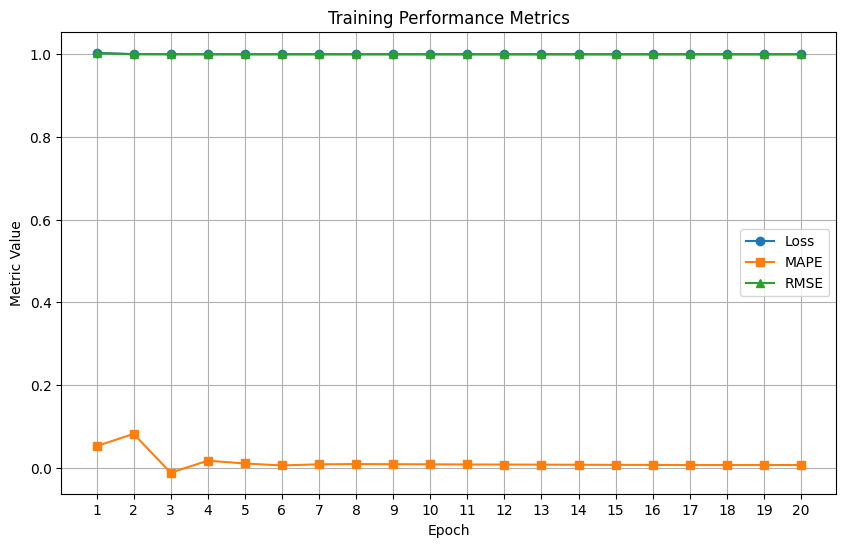

In [11]:
# prompt: plot a graph to conclude the following results
# Training result:
# Starting training...
# Epoch 1, Loss: 1.0031, MAPE: 0.0523, RMSE: 1.0015
# Epoch 2, Loss: 0.9995, MAPE: 0.0820, RMSE: 0.9998
# Epoch 3, Loss: 0.9993, MAPE: -0.0119, RMSE: 0.9996
# Epoch 4, Loss: 0.9992, MAPE: 0.0172, RMSE: 0.9996
# Epoch 5, Loss: 0.9992, MAPE: 0.0104, RMSE: 0.9996
# Epoch 6, Loss: 0.9992, MAPE: 0.0057, RMSE: 0.9996
# Epoch 7, Loss: 0.9992, MAPE: 0.0084, RMSE: 0.9996
# Epoch 8, Loss: 0.9992, MAPE: 0.0090, RMSE: 0.9996
# Epoch 9, Loss: 0.9992, MAPE: 0.0087, RMSE: 0.9996
# Epoch 10, Loss: 0.9991, MAPE: 0.0084, RMSE: 0.9996
# Epoch 11, Loss: 0.9991, MAPE: 0.0080, RMSE: 0.9996
# Epoch 12, Loss: 0.9991, MAPE: 0.0078, RMSE: 0.9996
# Epoch 13, Loss: 0.9991, MAPE: 0.0076, RMSE: 0.9996
# Epoch 14, Loss: 0.9991, MAPE: 0.0073, RMSE: 0.9996
# Epoch 15, Loss: 0.9991, MAPE: 0.0071, RMSE: 0.9996
# Epoch 16, Loss: 0.9991, MAPE: 0.0069, RMSE: 0.9996
# Epoch 17, Loss: 0.9991, MAPE: 0.0067, RMSE: 0.9996
# Epoch 18, Loss: 0.9991, MAPE: 0.0066, RMSE: 0.9996
# Epoch 19, Loss: 0.9991, MAPE: 0.0067, RMSE: 0.9996
# Epoch 20, Loss: 0.9991, MAPE: 0.0068, RMSE: 0.9996
# Training finished

import matplotlib.pyplot as plt

# Sample data from the provided output (replace with actual data if available)
epochs = list(range(1, 21))
loss_values = [1.0031, 0.9995, 0.9993, 0.9992, 0.9992, 0.9992, 0.9992, 0.9992, 0.9992, 0.9991, 0.9991, 0.9991, 0.9991, 0.9991, 0.9991, 0.9991, 0.9991, 0.9991, 0.9991, 0.9991]
mape_values = [0.0523, 0.0820, -0.0119, 0.0172, 0.0104, 0.0057, 0.0084, 0.0090, 0.0087, 0.0084, 0.0080, 0.0078, 0.0076, 0.0073, 0.0071, 0.0069, 0.0067, 0.0066, 0.0067, 0.0068]
rmse_values = [1.0015, 0.9998, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996, 0.9996]


plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_values, label='Loss', marker='o')
plt.plot(epochs, mape_values, label='MAPE', marker='s')
plt.plot(epochs, rmse_values, label='RMSE', marker='^')

plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('Training Performance Metrics')
plt.xticks(epochs)  # Ensure all epochs are shown on x-axis
plt.legend()
plt.grid(True)
plt.show()